# Model Training

### Step 1: Imports & Setup

We'll use scikit-learn for our modeling pipeline and joblib to save our final model.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from category_encoders import TargetEncoder
import joblib

# Set visualization style
sns.set_theme(style="whitegrid")

### Step 2: Load the Engineered Data

Loading the cleaned and feature-engineered dataset tracked by DVC.

In [7]:
data_path = '../data/processed/cleaned_retail_sales.csv'
df = pd.read_csv(data_path)

# Let's take a quick look to ensure it loaded correctly
display(df.head())
print(f"Dataset shape: {df.shape}")

,store_id,item_id,category,subcategory,price,demand,country,city_tier,date,year,month,day_of_week,is_weekend
0,371,item_1,Home,Furniture,248.55,41,Ghana,Tier 2 (Mid-level),2019-01-01,2019,1,1,0
1,371,item_1,Home,Furniture,293.63,53,Ghana,Tier 2 (Mid-level),2019-01-02,2019,1,2,0
2,371,item_1,Home,Furniture,264.27,39,Ghana,Tier 2 (Mid-level),2019-01-03,2019,1,3,0
3,371,item_1,Home,Furniture,252.64,35,Ghana,Tier 2 (Mid-level),2019-01-04,2019,1,4,0
4,371,item_1,Home,Furniture,248.59,51,Ghana,Tier 2 (Mid-level),2019-01-05,2019,1,5,1


Dataset shape: (4565000, 13)


### Step 3: Feature Selection

We define our target variable (`demand`) and separate our features. We will drop high-cardinality IDs and raw dates to prevent memory crashes and overfitting.

In [8]:
# Define target
target = 'demand'

# Define features
# Dropping 'date' (we have year/month/day), 'store_id' and 'item_id' (too many unique values for standard encoding)
features = [
    'store_id', 'price', 'category', 'subcategory', 'country',
    'city_tier', 'year', 'month', 'day_of_week', 'is_weekend'
]

X = df[features]
y = df[target]

# Identify numerical and categorical columns for the pipeline
numeric_features = ['price', 'year', 'month', 'day_of_week']
low_cardinality_features = ['category', 'country', 'city_tier', 'is_weekend']

# store_id and subcategory have too many unique values for One-Hot Encoding
high_cardinality_features = ['store_id', 'subcategory']

print(f"Features selected: {len(features)}")

Features selected: 10


### Step 4: Train-Test Split

Splitting the data 80/20 so we can evaluate the model on unseen data.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (3652000, 10)
Testing data shape: (913000, 10)


### Step 5: Build the Pipeline

We create a preprocessing step to scale numbers and encode categories, then feed it directly into a Random Forest Regress

#### Expanation of the code below

The code written below constructs a machine learning pipeline that includes both preprocessing and modeling steps. In the preprocessing we made use of standard scaling for numerical features, one-hot encoding for low-cardinality categorical features, and target encoding for high-cardinality categorical features. The model used is a Random Forest Regressor, which is a powerful ensemble learning method that can capture complex relationships in the data. By combining all these steps into a single pipeline, we ensure that the same transformations are applied consistently during both training and prediction, which helps to prevent data leakage and makes the code cleaner and more maintainable.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat_low', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_cardinality_features),
        ('cat_high', TargetEncoder(), high_cardinality_features) # <--- TARGET ENCODING MAGIC
    ])

# 2. Complete Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_low', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

### Step 6: Train the Model

This might take a minute depending on the size of the dataset. The `n_jobs=-1` tells Python to use all CPU cores.

In [11]:
print("Training the Random Forest model...")
model_pipeline.fit(X_train, y_train)
print("Training complete!")

Training the Random Forest model...
Training complete!


### Step 7: Model Evaluation

Let's see how well our model predicts demand based on price and context.

--- Model Performance ---
RMSE (Root Mean Squared Error): 34.93
MAE (Mean Absolute Error): 18.74
R-squared: 0.8440


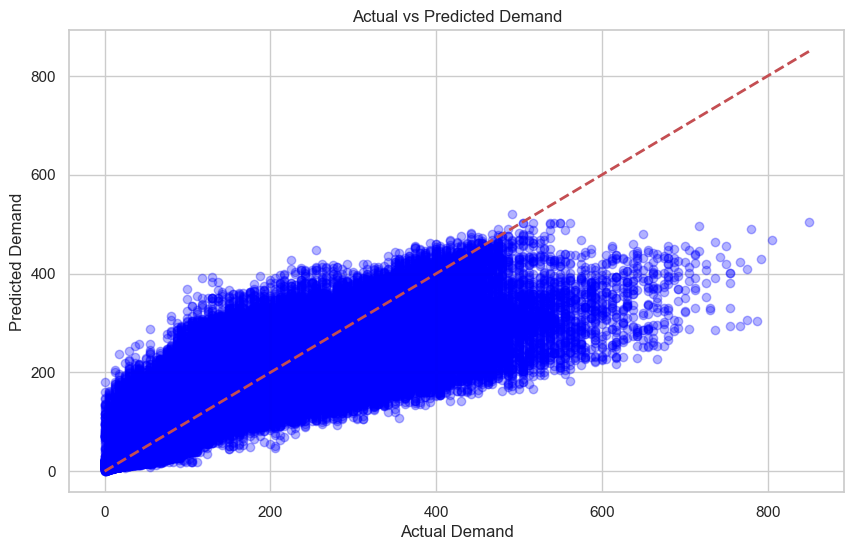

In [13]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"R-squared: {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Demand')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.show()

### Step 8: Feature Importance

Let's prove that our newly engineered features (especially `price`) are actually driving the predictions.

C:\Users\ginik\AppData\Local\Temp\ipykernel_14884\2631965024.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


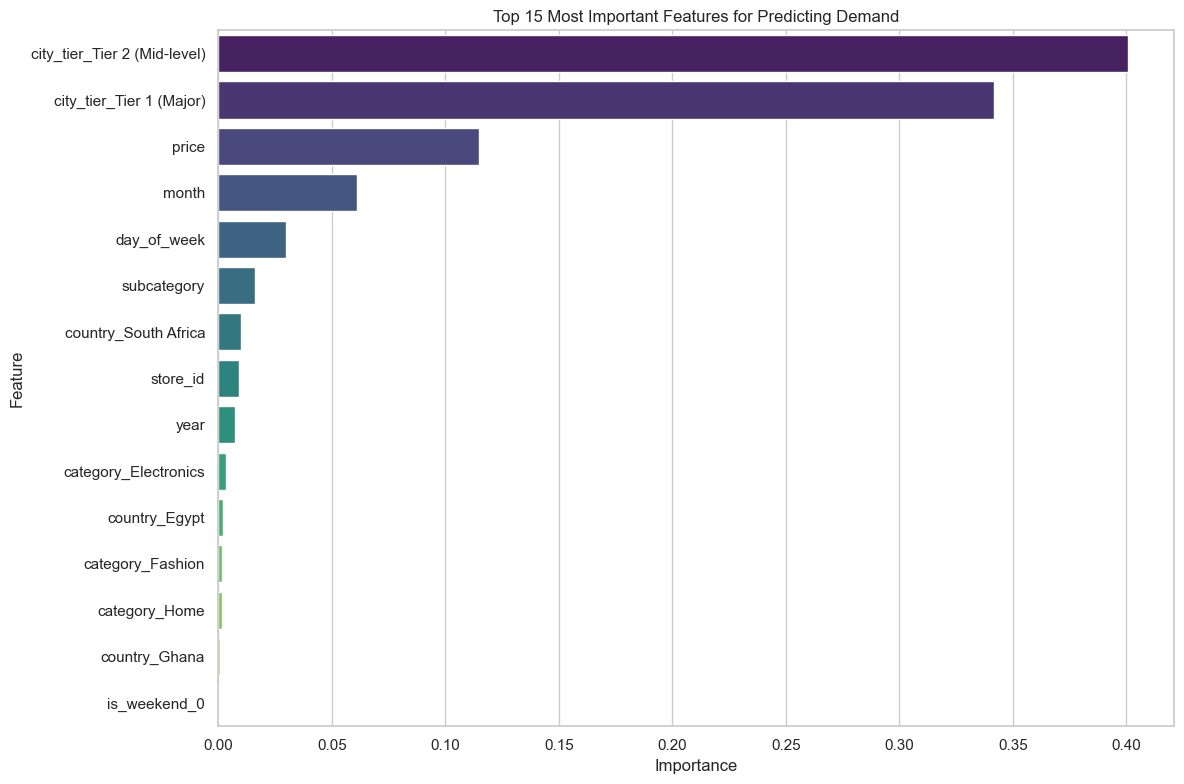

In [14]:
# 1. Extract feature names from the OneHotEncoder (cat_low)
cat_low_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat_low']
cat_low_feature_names = cat_low_encoder.get_feature_names_out(low_cardinality_features)

# 2. Get feature names for the TargetEncoder (cat_high)
# Target encoding just replaces the ID with a number, so the column names don't change!
cat_high_feature_names = high_cardinality_features

# 3. Combine ALL feature names in the exact order the ColumnTransformer outputs them
# (Order: num -> cat_low -> cat_high)
all_feature_names = np.concatenate([
    numeric_features,
    cat_low_feature_names,
    cat_high_feature_names
])

# Get feature importances from the Random Forest
importances = model_pipeline.named_steps['regressor'].feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Demand')
plt.tight_layout()
plt.show()

### Step 9: Save the Model
We export the entire trained pipeline (preprocessing + model) as a single file.
This makes it incredibly easy to load into our final app later.

In [15]:
import os

# Ensure the models directory exists
os.makedirs('../models', exist_ok=True)

model_path = '../models/demand_prediction_model.pkl'
joblib.dump(model_pipeline, model_path)

print(f"Model successfully saved to: {model_path}")

Model successfully saved to: ../models/demand_prediction_model.pkl
